# **Auditoría De Calidad De Datos**

Integrantes: Juan Diego Serpa Ruiz, Juan Esteban Camacho Castro

## **1 Carga de librerías y dataset**

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [5]:
df = pd.read_csv("NovaMarket_datos_crudos.csv")

## **2 Conteo de nulos**

In [10]:
df.isnull().sum()

id_pedido                         0
id_cliente                        0
fecha_pedido                      0
canal_compra                      0
metodo_pago                       0
ciudad_tienda                 29928
codigo_postal                     0
categoria_producto                0
producto                          0
precio_unitario               21640
unidades_vendidas                 0
monto_compra                  21640
edad_cliente                      0
correo_cliente               105312
nivel_satisfaccion            46469
nivel_lealtad                     0
comentario_cliente            90806
peso_pedido_kg                    0
fecha_actualizacion_stock         0
fuga_cliente                      0
dtype: int64

### Columnas a diagnosticar

A partir del resultado de `df.isnull().sum()`, se identificaron las columnas que serán diagnosticadas durante esta semana y la cantidad exacta de registros faltantes en cada una:

* **`correo_cliente`**: 105.312 registros faltantes.
* **`nivel_satisfaccion`**: 46.469 registros faltantes.
* **`ciudad_tienda`**: 29.928 registros faltantes.
* **`precio_unitario`**: 21.640 registros faltantes.

Estas columnas fueron seleccionadas debido a que presentan valores faltantes que requieren un análisis posterior para determinar su comportamiento y el tratamiento adecuado.


## **Mapa de calor**

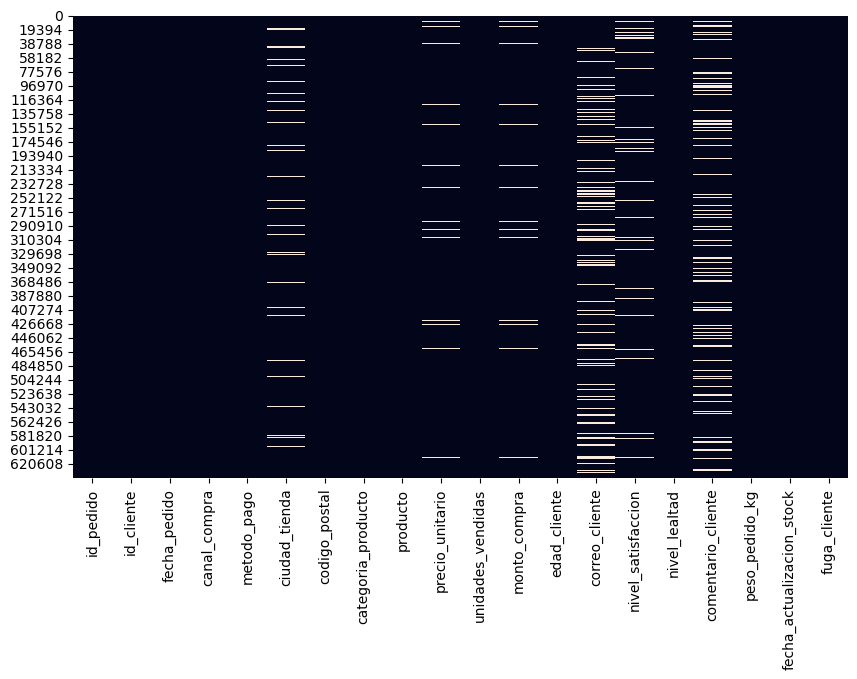

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

<Axes: >

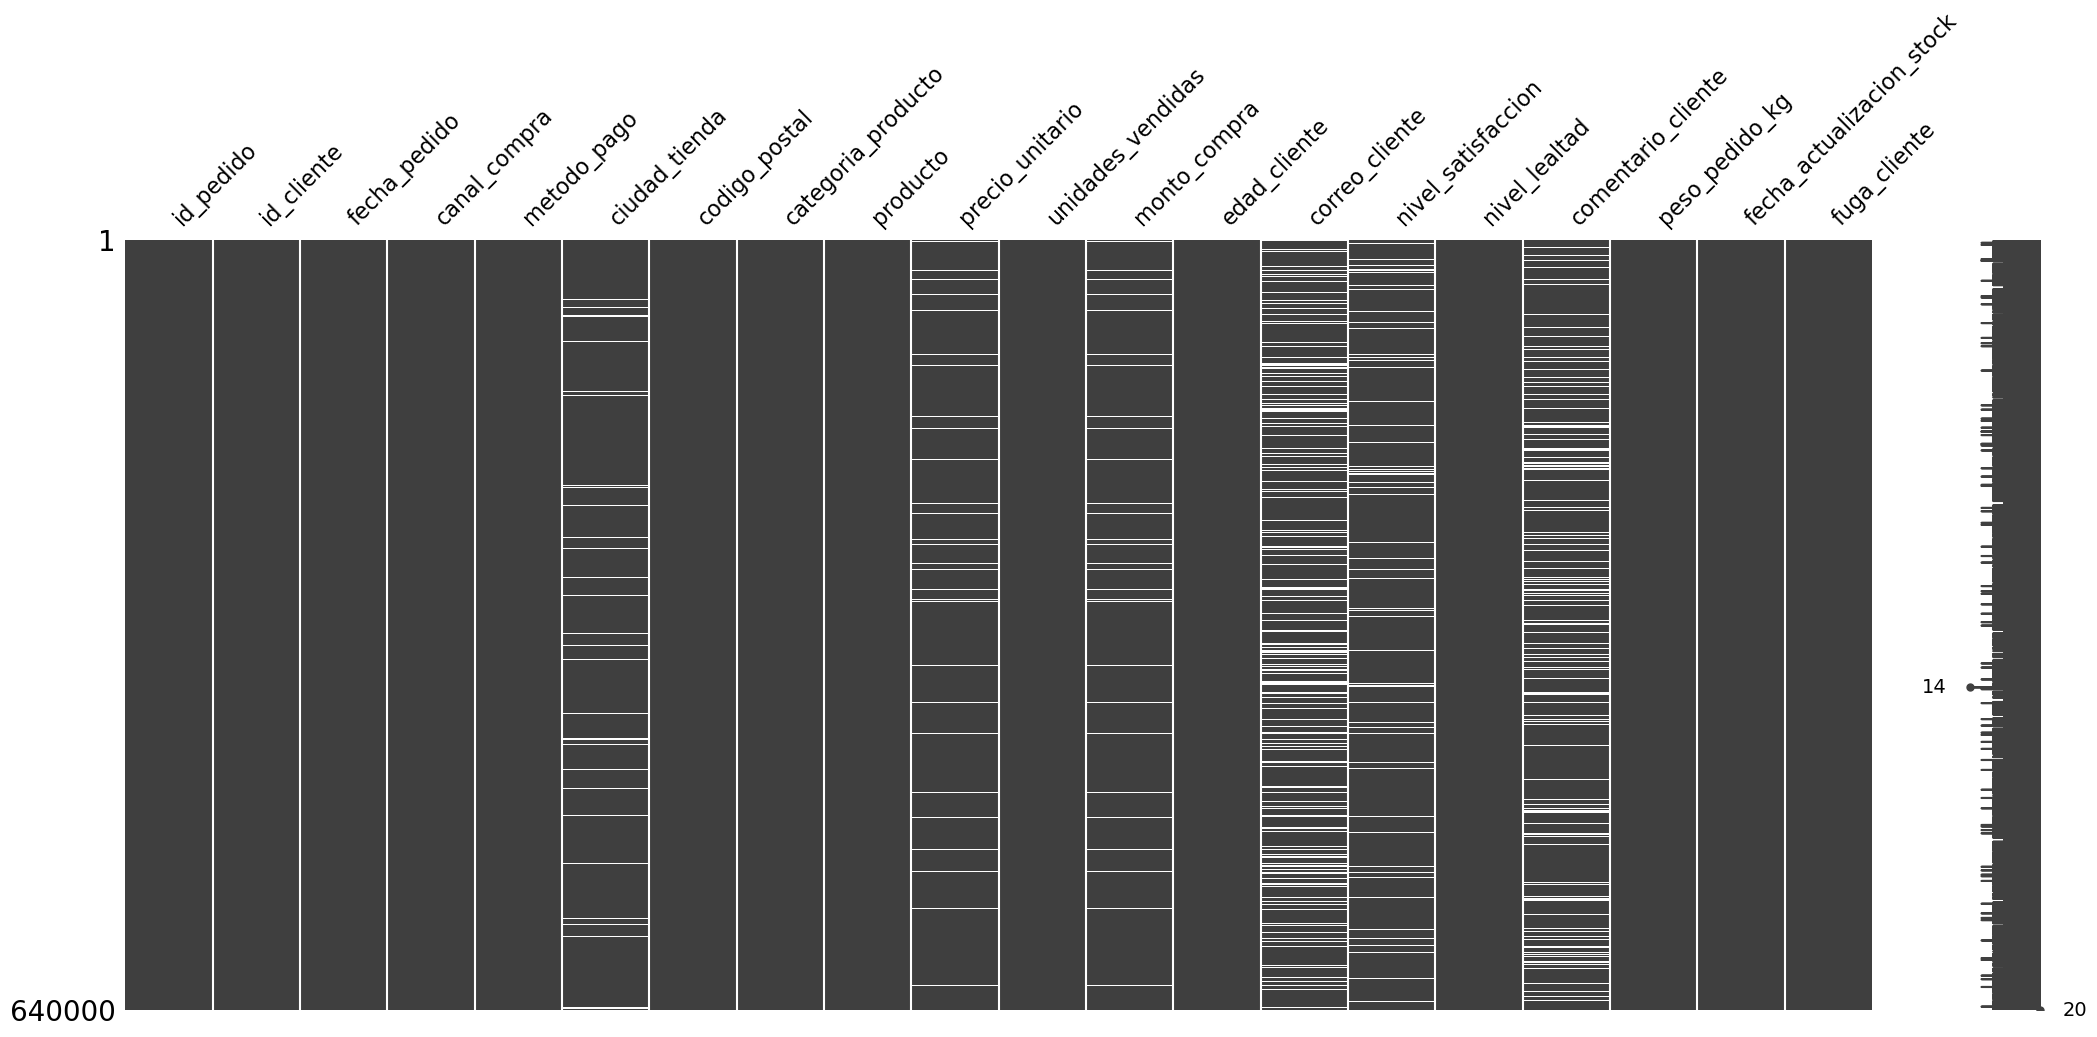

In [12]:
msno.matrix(df)

El mapa de valores nulos muestra que los datos faltantes se encuentran principalmente concentrados en algunas columnas específicas, mientras que la mayoría de las variables están completas. Se observa que precio_unitario y monto_compra presentan faltantes simultáneos en los mismos registros, lo que podría indicar una causa común. Por otro lado, los faltantes de correo_cliente y comentario_cliente son numerosos, mientras que los de nivel_satisfaccion y ciudad_tienda aparecen de forma más dispersa.

## **3 MCAR**

## precio_unitario

In [13]:
df[df["precio_unitario"].isnull()]["categoria_producto"].value_counts(normalize=True)

categoria_producto
Electrónica     0.089556
Hogar           0.089510
Belleza         0.088170
Deportes        0.087015
Moda            0.084750
Juguetería      0.082671
belleza         0.033965
hogar           0.032856
deportes        0.032348
moda            0.029020
Deportes        0.017098
 Belleza        0.016821
 Moda           0.016821
JUGUETERÍA      0.016590
electronica     0.016497
Electrónica     0.016266
HOGAR           0.016174
MODA            0.016128
Hogar           0.016081
juguetería      0.016035
 Deportes       0.015989
DEPORTES        0.015989
Juguetería      0.015896
 Hogar          0.015665
ELECTRÓNICA     0.015665
BELLEZA         0.015573
 Juguetería     0.015527
Belleza         0.015481
electrónica     0.015296
 Electrónica    0.015203
jugueteria      0.014972
Moda            0.014372
Name: proportion, dtype: float64

In [14]:
df["categoria_producto"].value_counts(normalize=True)

categoria_producto
Belleza         0.088091
Electrónica     0.087908
Deportes        0.087530
Hogar           0.087259
Juguetería      0.086717
Moda            0.086406
moda            0.031803
hogar           0.031800
deportes        0.031798
belleza         0.031677
electronica     0.016302
JUGUETERÍA      0.016144
HOGAR           0.016078
Electrónica     0.016042
DEPORTES        0.016037
Deportes        0.015959
Belleza         0.015930
Moda            0.015909
 Juguetería     0.015891
Hogar           0.015870
 Deportes       0.015855
electrónica     0.015847
 Moda           0.015838
juguetería      0.015833
BELLEZA         0.015803
ELECTRÓNICA     0.015758
 Belleza        0.015706
Juguetería      0.015698
jugueteria      0.015670
MODA            0.015664
 Electrónica    0.015637
 Hogar          0.015539
Name: proportion, dtype: float64

### Diagnóstico de precio_unitario

Al comparar la distribución de categoria_producto entre los registros donde precio_unitario es faltante y la distribución general del dataset, se observa que las proporciones son, en general, similares. Por ejemplo, las categorías principales presentan diferencias pequeñas entre ambas distribuciones. Esto indica que no se evidencia una relación clara entre la ausencia de precio_unitario y la categoría del producto.

Por lo tanto, con base únicamente en esta comparación, los datos faltantes de precio_unitario son compatibles con la hipótesis MCAR, aunque esta prueba por sí sola no permite confirmarla completamente, ya que sería necesario analizar otras variables.

## **4 MAR**

## canal_compra y nivel_satisfaccion

In [15]:
df.groupby("canal_compra")["nivel_satisfaccion"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            19.7
 Marketplace     3.2
 Tienda          2.6
 Web             2.8
APP             19.9
App             20.4
App             19.9
MARKETPLACE      2.6
Marketplace      2.9
Marketplace      3.0
TIENDA           3.2
Tienda           3.0
Tienda           3.2
WEB              2.9
Web              2.8
Web              2.8
app             20.9
marketplace      2.9
tienda           2.9
web              2.8
Name: nivel_satisfaccion, dtype: float64

### Diagnóstico de nivel_satisfaccion

Al analizar el porcentaje de valores faltantes de nivel_satisfaccion según canal_compra, se observa una diferencia marcada entre los grupos. Los registros asociados al canal App presentan aproximadamente entre 19,7 % y 20,9 % de valores faltantes, mientras que los demás canales presentan porcentajes cercanos al 2,6 %–3,2 %.

Por lo tanto, los faltantes de nivel_satisfaccion muestran un patrón relacionado con canal_compra, ya que la tasa de ausencia en App es varias veces superior a la de los demás canales. Esto proporciona evidencia de que los datos faltantes son MAR (Missing At Random), dado que su ausencia está asociada con una variable observable del dataset.

También se observa que canal_compra presenta diferentes formas de escritura, como App, APP, app y App, lo que debería ser corregido posteriormente durante la limpieza de los datos.

### canal_compra y ciudad_tienda

In [16]:
df.groupby("canal_compra")["ciudad_tienda"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            4.6
 Marketplace    4.7
 Tienda         4.8
 Web            4.7
APP             4.9
App             4.7
App             5.0
MARKETPLACE     4.7
Marketplace     4.6
Marketplace     4.6
TIENDA          5.0
Tienda          4.7
Tienda          4.5
WEB             4.9
Web             4.7
Web             5.1
app             4.7
marketplace     4.6
tienda          4.7
web             4.5
Name: ciudad_tienda, dtype: float64

### categoria_producto y ciudad_tienda

In [17]:
df.groupby("categoria_producto")["ciudad_tienda"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
 Belleza        4.6
 Deportes       4.8
 Electrónica    4.7
 Hogar          4.8
 Juguetería     4.7
 Moda           5.0
BELLEZA         4.9
Belleza         4.6
Belleza         4.7
DEPORTES        4.9
Deportes        4.6
Deportes        4.6
ELECTRÓNICA     4.6
Electrónica     4.6
Electrónica     5.0
HOGAR           4.6
Hogar           4.6
Hogar           4.4
JUGUETERÍA      5.0
Juguetería      4.7
Juguetería      4.8
MODA            4.7
Moda            4.7
Moda            4.6
belleza         4.7
deportes        4.6
electronica     4.9
electrónica     4.4
hogar           4.6
jugueteria      4.8
juguetería      4.6
moda            4.7
Name: ciudad_tienda, dtype: float64

### Diagnóstico de ciudad_tienda

Al analizar la tasa de valores faltantes de ciudad_tienda según canal_compra y categoria_producto, se observa que los porcentajes se mantienen muy similares entre los diferentes grupos. Para canal_compra, los valores se encuentran aproximadamente entre 4,5 % y 5,1 %, mientras que para categoria_producto se encuentran entre 4,4 % y 5,0 %.

No se observa un grupo con una tasa de faltantes considerablemente mayor que los demás. Por lo tanto, no se encuentra evidencia de que las variables observadas analizadas expliquen la ausencia de ciudad_tienda. Con la evidencia disponible, los faltantes son compatibles con MCAR.

### canal_compra y correo_cliente

In [18]:
df.groupby("canal_compra")["correo_cliente"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            16.6
 Marketplace    16.1
 Tienda         15.9
 Web            16.9
APP             16.3
App             16.6
App             16.1
MARKETPLACE     16.5
Marketplace     16.3
Marketplace     15.4
TIENDA          16.5
Tienda          16.5
Tienda          16.5
WEB             16.3
Web             16.5
Web             17.2
app             16.1
marketplace     16.6
tienda          16.7
web             15.8
Name: correo_cliente, dtype: float64

### categoria_producto y correo_cliente

In [19]:
df.groupby("categoria_producto")["correo_cliente"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
 Belleza        16.4
 Deportes       17.0
 Electrónica    16.7
 Hogar          16.7
 Juguetería     15.8
 Moda           16.3
BELLEZA         17.4
Belleza         16.5
Belleza         16.0
DEPORTES        16.8
Deportes        16.2
Deportes        16.6
ELECTRÓNICA     16.1
Electrónica     16.5
Electrónica     16.8
HOGAR           16.7
Hogar           16.5
Hogar           16.2
JUGUETERÍA      15.7
Juguetería      16.4
Juguetería      16.4
MODA            16.7
Moda            16.3
Moda            16.5
belleza         16.5
deportes        16.5
electronica     16.0
electrónica     16.2
hogar           16.6
jugueteria      16.5
juguetería      15.9
moda            17.0
Name: correo_cliente, dtype: float64

### Diagnóstico de correo_cliente

Al analizar la tasa de valores faltantes de correo_cliente según canal_compra y categoria_producto, se observa que los porcentajes son similares entre los diferentes grupos. Para canal_compra, las tasas se encuentran aproximadamente entre 15,4 % y 17,2 %, mientras que para categoria_producto se encuentran entre 15,7 % y 17,4 %.

Las diferencias entre los grupos son pequeñas y no se identifica un patrón claro que indique que estas variables expliquen los valores faltantes. Por lo tanto, con las variables observadas analizadas, los faltantes de correo_cliente son compatibles con MCAR. No obstante, podría considerarse una hipótesis de MNAR si el conocimiento del proceso de negocio indicara que la decisión de proporcionar el correo está relacionada con la probabilidad de que este dato quede vacío.

## **Tabla de decisiones**

Con base en el diagnóstico realizado en las secciones anteriores, se arma la siguiente tabla que resume, para cada columna con vacíos, qué mecanismo se identificó, qué estrategia se decidió aplicar y por qué.

| Columna | Mecanismo | % faltante | Estrategia elegida | Justificación |
|---|---|---|---|---|
| `precio_unitario` | MCAR | 3,38 % | Eliminar filas | El diagnóstico mostró que la distribución de `categoria_producto` en los registros con faltantes es muy parecida a la general. Como es MCAR y está por debajo del 5 %, eliminar filas es la opción más segura. |
| `monto_compra` | MCAR | 3,38 % | Eliminar filas | Los faltantes de `monto_compra` coinciden exactamente con los de `precio_unitario` (se ve en el mapa de calor). Se eliminan en el mismo `dropna()` para conservar la coherencia entre las dos columnas. |
| `nivel_satisfaccion` | MAR | 7,26 % | Imputación por grupo (`canal_compra`) | El canal *App* concentra alrededor del 20 % de nulos, mientras que los demás canales están cerca del 5 %. Es decir, `canal_compra` explica el faltante, por eso se imputa con la moda dentro de cada grupo. |
| `ciudad_tienda` | MCAR | 4,68 % | Imputación constante (`"Desconocida"`) | Las tasas de faltantes son parecidas entre grupos (entre 4,5 % y 5,1 %), no hay una columna que explique el vacío. Como es una categórica, se rellena con un valor constante para conservar las filas sin inventar una ciudad específica. |
| `correo_cliente` | MNAR (sospechada) | 16,46 % | Columna indicadora, sin imputar el valor | Aunque las tasas entre grupos son parecidas, un 16 % es demasiado alto para asumir MCAR puro. Es más razonable pensar que muchos clientes simplemente no quisieron dejar su correo. No se puede inventar un correo, así que solo se marca con una columna indicadora. |
| `comentario_cliente` | MNAR (sospechada) | 14,19 % | Columna indicadora, sin imputar el valor | Es esperable que muchos clientes no dejen comentario. El que no lo dejó probablemente no lo iba a dejar nunca (mecanismo MNAR). No tiene sentido inventar un comentario, se deja la columna indicadora como registro de que faltaba. |

## **Eliminación de filas**

Antes y después del **dropna()** se imprime **df.shape** para verificar que la cantidad de filas eliminadas coincida con lo esperado.

In [6]:
print("Antes de eliminar:", df.shape)
df = df.dropna(subset=["precio_unitario", "monto_compra"])
print("Después de eliminar:", df.shape)

Antes de eliminar: (640000, 20)
,Después de eliminar: (618360, 20)


Antes del *dropna()* el dataset tenía **640.000 filas** y después quedó con **618.360.** Se eliminaron exactamente **21.640 filas**, que es justo la cantidad de faltantes que reportaba *precio_unitario* (y también *monto_compra*) en la auditoría. La coincidencia confirma que la eliminación se aplicó bien y que los faltantes de las dos columnas estaban efectivamente en las mismas filas.

## **Columnas indicadoras**

Antes de imputar cualquier valor, se crean las columnas indicadoras para las 4 columnas que sí se van a tratar (imputar o dejar marcadas como MNAR). 

Cada indicadora es una columna booleana que vale **True** donde el valor original estaba vacío y **False** donde no.

In [7]:
df["nivel_satisfaccion_imputado"] = df["nivel_satisfaccion"].isnull()
df["ciudad_tienda_imputado"] = df["ciudad_tienda"].isnull()
df["correo_cliente_imputado"] = df["correo_cliente"].isnull()
df["comentario_cliente_imputado"] = df["comentario_cliente"].isnull()

# Verificacion
print("nivel_satisfaccion_imputado:", df["nivel_satisfaccion_imputado"].sum())
print("ciudad_tienda_imputado:", df["ciudad_tienda_imputado"].sum())
print("correo_cliente_imputado:", df["correo_cliente_imputado"].sum())
print("comentario_cliente_imputado:", df["comentario_cliente_imputado"].sum())

nivel_satisfaccion_imputado: 44892
,ciudad_tienda_imputado: 28927
,correo_cliente_imputado: 101636
,comentario_cliente_imputado: 87733


## **Imputación por columna**

### **nivel_satisfaccion** — imputación por grupo (MAR)

In [9]:
df["nivel_satisfaccion"] = df.groupby("canal_compra")["nivel_satisfaccion"].transform(
    lambda s: s.fillna(s.mode()[0])
)

Como el diagnóstico mostró que *canal_compra* es la columna que explica los faltantes de *nivel_satisfaccion*, la imputación se hace **por grupo**: dentro de cada canal se rellenan los vacíos con la moda de ese mismo canal. Así se respeta el patrón de comportamiento de cada canal en vez de imponer un solo valor global.

### **ciudad_tienda**

In [10]:
df["ciudad_tienda"] = df["ciudad_tienda"].fillna("Desconocida")

Como `ciudad_tienda` no tiene un grupo claro que explique sus faltantes y es una variable categórica, no se puede imputar por grupo. Se rellena con un valor constante `"Desconocida"`, que es honesto: no inventa una ciudad específica y deja marcado que ese dato faltaba en el origen.

### 8.3 **correo_cliente** y **comentario_cliente** — no se imputan (MNAR)

Estas dos columnas no se imputan. La razón es que el mecanismo diagnosticado es MNAR: el faltante depende del propio valor que falta. Es muy probable que muchos clientes simplemente **decidieron no dejar su correo o su comentario**, y no existe forma razonable de reconstruir esa información sin inventarla.

Por eso el tratamiento principal para estas dos columnas son las **columnas indicadoras** creadas anteriormente lo que deja constancia de qué registros venían vacíos.

### 8.4 Verificación final

In [11]:
df.isnull().sum()

id_pedido                           0
id_cliente                          0
fecha_pedido                        0
canal_compra                        0
metodo_pago                         0
ciudad_tienda                       0
codigo_postal                       0
categoria_producto                  0
producto                            0
precio_unitario                     0
unidades_vendidas                   0
monto_compra                        0
edad_cliente                        0
correo_cliente                 101636
nivel_satisfaccion                  0
nivel_lealtad                       0
comentario_cliente              87733
peso_pedido_kg                      0
fecha_actualizacion_stock           0
fuga_cliente                        0
nivel_satisfaccion_imputado         0
ciudad_tienda_imputado              0
correo_cliente_imputado             0
comentario_cliente_imputado         0
dtype: int64

Después de aplicar todas las estrategias, **df.isnull().sum()** debe mostrar 0 faltantes en las columnas que se decidieron imputar (**nivel_satisfaccion** y **ciudad_tienda**) y conservar los faltantes originales en las dos columnas MNAR (**correo_cliente** y **comentario_cliente**), que fue una decisión justificada. Las columnas **precio_unitario** y **monto_compra** también quedan en 0 porque las filas con vacíos ya se eliminaron.

## **Exportación del dataset**

In [12]:
df.to_csv("S04_PD_Camacho,Serpa,Rueda,Gonzáles.csv", index=False)